# **Task 4**

## **DJS Synapse Learning Period**
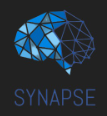

Congratulations on making it this far!! Welcome to the world of classification where we move on from unsupervised to helping the algorithms by telling them exactly what the data we're feeding them is. This week we'll be looking into  many algorithms such as Decision Trees, SVC, Naive Bayes, Random Forest and so on. We'll also be delving into hyperparameter tuning the only place where ched chaad can lead to a good result.

**Warning: This task contains many theory questions. Proceed with caution!**

Jk, make sure you research well and make sure you are understanding the models y'all are implementing as that will make your concepts much stronger and build a strong ML foundation which will be very useful as we move further with the tasks.

### Overfitting and Underfitting [VERY IMPORTANT]:
https://www.youtube.com/watch?v=T9NtOa-IITo
Note : This concept can be seen in K Means and decision trees. In fact, we will look deeper into
this when we begin deep learning.

## Importing the dataset

Use this link to download the adult income dataset and upload it to your drive.

https://drive.google.com/file/d/1VAE1qF16D-sKnBOWXzGXVNGhtNZNLFQS/view?usp=sharing

In [24]:


import sklearn 
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
#import your dataset here
df = pd.read_csv('adult_income_dataset.csv')
df.head()



,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Dealing with Nan values

In [26]:
#write a code to find the nan values for the dataset and make a decision on whether to dropna or fill na
df.isna().sum()


age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [27]:
df.dropna(inplace=True)
df.shape

(30162, 15)

## Object Valued Columns

For Relationship, Race and Sex find out the max division average fnlwgt for each unique value.

## Getting rid of unnecessary columns

*   Drop the education num column since we already have their education in the form of categories
*   Check the combinations of the marital-status and relationship column, see if we need both of them or just marital status will work too.


In [28]:
#write your code here
df = df.drop_duplicates()
df.drop(columns=['education-num'], inplace=True)
df.drop(columns=['relationship'], inplace=True)
df.drop(columns=['fnlwgt'], inplace=True)

print(df.head())


   age         workclass  education      marital-status         occupation  \
0   39         State-gov  Bachelors       Never-married       Adm-clerical   
1   50  Self-emp-not-inc  Bachelors  Married-civ-spouse    Exec-managerial   
2   38           Private    HS-grad            Divorced  Handlers-cleaners   
3   53           Private       11th  Married-civ-spouse  Handlers-cleaners   
4   28           Private  Bachelors  Married-civ-spouse     Prof-specialty   

    race     sex  capital-gain  capital-loss  hours-per-week native-country  \
0  White    Male          2174             0              40  United-States   
1  White    Male             0             0              13  United-States   
2  White    Male             0             0              40  United-States   
3  Black    Male             0             0              40  United-States   
4  Black  Female             0             0              40           Cuba   

  income  
0  <=50K  
1  <=50K  
2  <=50K  
3  <=50K  
4

## Dealing with Categorical Data
As you probably know by now, the ML models dont know how to deal with String or object type data... so your mission shall you choose to accept it (don't really have much of a choice) is to find out which columns to do one hot encoding on and which columns to do Label Encoding on.

**Hint: Since Marital-status has less number of columns (distinct values na), One Hot encode it**

In [29]:
#Write your code here
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le = LabelEncoder()
ohe = OneHotEncoder(sparse_output=False)
df['sex'] = le.fit_transform(df['sex'])
ohe_cols = ['workclass', 'education', 'marital-status', 'occupation', 'race', 'native-country']
encoded = ohe.fit_transform(df[ohe_cols])
df[ohe.get_feature_names_out(ohe_cols)] = encoded
df.drop(columns=ohe_cols, inplace=True)
df['income'] = le.fit_transform(df['income'])



#Hint: Check which needs one hot encoding which needs label encoding
#Then perform necessary transformations (Feel free to add more coding cells)

## Altering the Target Column
Modify the Target Column (income) to make sure that all the values which are <=50K are replaced with a 0 and the values >50K are replaced with a 1.

In [30]:
#write your code here
print(df.head())


   age  sex  capital-gain  capital-loss  hours-per-week  income  \
0   39    1          2174             0              40       0   
1   50    1             0             0              13       0   
2   38    1             0             0              40       0   
3   53    1             0             0              40       0   
4   28    0             0             0              40       0   

   workclass_Federal-gov  workclass_Local-gov  workclass_Private  \
0                    0.0                  0.0                0.0   
1                    0.0                  0.0                0.0   
2                    0.0                  0.0                1.0   
3                    0.0                  0.0                1.0   
4                    0.0                  0.0                1.0   

   workclass_Self-emp-inc  ...  native-country_Portugal  \
0                     0.0  ...                      0.0   
1                     0.0  ...                      0.0   
2          

**Extract the target column(income) and store it in a seperate variable and remove it from the original dataset. Additionally, do a 70:30 Train Test Split**

In [31]:
#write your code here
y = df['income']
df.drop(columns = ['income'],inplace=True)
X = df.iloc[:,:]
print(y.head())


0    0
1    0
2    0
3    0
4    0
Name: income, dtype: int64


### Chalo now that we have the preprocessed data we can feed it into the models. Lets start with some basic ones.

# Logistic Regression
*   Theory:https://www.youtube.com/watch?v=yIYKR4sgzI8&list=PLblh5JKOoLUKxzEP5HA2d-Li7IJkHfXSe
*   Implementation: https://www.youtube.com/watch?v=n40hS9tQmcY


Explain the algorithm, its working and its use cases.

In [32]:
#import the model and apply it to the data
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.3, random_state=42)
model = LogisticRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Find the accuracy and confusion matrix for the same and explain what it shows.

In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.843065693430657
[[6320  429]
 [ 990 1303]]


### Now that you have printed a confusion matrix and classification report. Let's see what you have understood from it. Write a short paragraph highlighting what you understoood from it below.

# Naive Bayes Algorithm

* Theory : https://youtu.be/jS1CKhALUBQ
* Theory:
https://www.analyticsvidhya.com/blog/2021/09/naive-bayes-algorithm-a-complete-guide-for-data-science-enthusiasts/
* Implementation : https://youtu.be/nHIUYwN-5rM

In [34]:
#import the model from sklearn and apply it to your data
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.3, random_state=42)
model = GaussianNB()


# Make predictions
model.fit(X_train,y_train)
y_pred = model.predict(X_test)



# Calculate accuracy
print(accuracy_score(y_test,y_pred))

0.831895598318956


# Decision Tree Classifier
* Theory : https://youtu.be/7VeUPuFGJHk
* Theory: https://www.analyticsvidhya.com/blog/2021/08/decision-tree-algorithm/
* Implementation : https://youtu.be/HY2DcBhgwm0

In [35]:
#import the decision tree from sklearn and run it on your data
from sklearn.tree import DecisionTreeClassifier
DTC = DecisionTreeClassifier(criterion='gini',max_depth=10)
DTC.fit(X_train,y_train)
y_pred = DTC.predict(X_test)



<b>Print the Model Accuracy</b>

In [36]:
print(accuracy_score(y_test,y_pred))

0.8532404335324043


## Explain: What are the differences in the working of Logistic Regression, Naive Bayes and Decision Tree and explain why are the accuracies are different.

Ans:

### Mention some real life use cases for each of these three models:

Ans:

Now that you have your first result, make sure that you play with the hyperparameters to get a better result. Visualize results, try different hyperparameters by using a loop, GET CREATIVE!<br>

Machine learning is an iteritive process. You will have to keep playing with hyperparameters and algorithms. No fixed algorithm will work on a fixed dataset.

Take this up as a challenge. The person with the best accuracy wins the round!

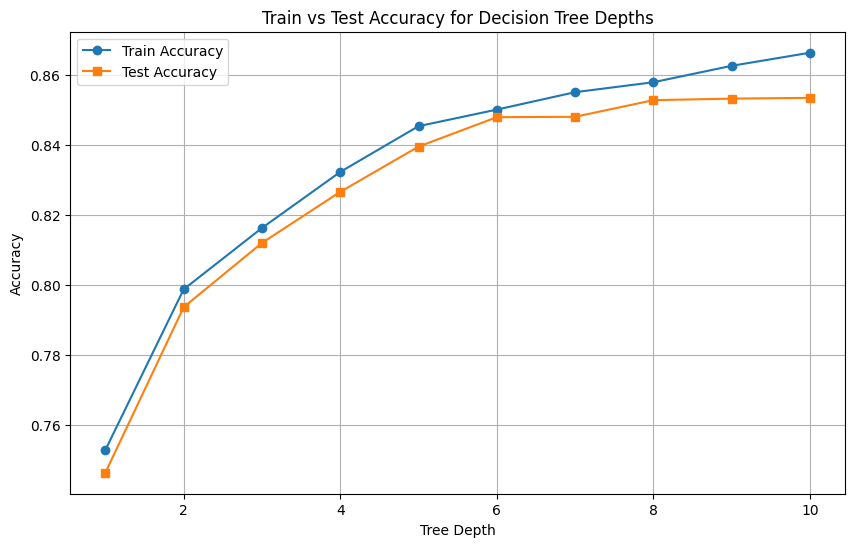

In [37]:
#plot a graph that shows the train and test accuracy for increasing depth of the tree (do for 10)
train_accuracies = []
test_accuracies = []
depths = range(1, 11)

# Loop through depths 1 to 10
for depth in depths:
    DTC = DecisionTreeClassifier(max_depth=depth, random_state=42)
    DTC.fit(X_train, y_train)
    
    train_pred = DTC.predict(X_train)
    test_pred = DTC.predict(X_test)
    
    train_accuracies.append(accuracy_score(y_train, train_pred))
    test_accuracies.append(accuracy_score(y_test, test_pred))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(depths, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(depths, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy for Decision Tree Depths')
plt.legend()
plt.grid(True)
plt.show()



In [38]:
#complete the code below to create an image of the decision tree
from sklearn import tree
%pip install graphviz
decision_tree = tree.export_graphviz(DTC, out_file='tree.dot', feature_names=X_train.columns, max_depth=2, filled=True)
%dot -Tpng tree.dot -o tree.png # to convert the file
image = plt.imread('tree.png')
plt.figure(figsize=(15,15))
plt.imshow(image)


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


UsageError: Line magic function `%dot` not found.


<b>print the test accuracy and train accuracy here</b>

In [39]:
#write code here
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))


0.8532404335324043
[[6389  360]
 [ 967 1326]]


### Explain the different hyperparameters you changed and how did it affect the models. Also give a summary of the graphs you made.

Ans:

## SUPPORT VECTOR MACHINE (SVM)

Theory : https://www.youtube.com/watch?v=efR1C6CvhmE (Part 1)

Theory: https://www.youtube.com/watch?v=H9yACitf-KM

Maths Intuition : https://www.youtube.com/watch?v=Js3GLb1xPhc

EXTRAS:

https://www.youtube.com/watch?v=NDqACjz5j8g

If you are more curious and want to explore :

https://www.youtube.com/watch?v=Toet3EiSFcM (Part 2)

https://www.youtube.com/watch?v=efR1C6CvhmE&t=432s (Part 3)

https://www.youtube.com/watch?v=8bFKyb77vp0




In [40]:
#Now that we know SVM is sensitive to feature scales, so standardize (don't forget to standardise your X_test):
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
from sklearn.svm import SVC

In [41]:
#Train your model
SVM = SVC(kernel='rbf', C=1.0, gamma='scale')


In [42]:
#Predict and check accuracies
SVM.fit(X_train,y_train)
y_pred = SVM.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.8462729484627295


In [43]:
#let's try out using different kernels now. Freedom to choose lies in your hands. EXPLOREEE!
model = SVC(kernel='linear', C=1.0, gamma='scale')
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.845056403450564


## BIAS AND VARIANCE
### Hurrayy! You have made it so far sane.

### Before moving forward let's first understand what exactly do you mean by bias and variance.

THEORY: https://www.geeksforgeeks.org/machine-learning/bias-vs-variance-in-machine-learning/ (explained in quite detail do read this not just video)

VIDEO: https://www.youtube.com/watch?v=EuBBz3bI-aA


## Optimizing Methods

We can even use Ensemble Methods like **bagging (random forest)**, **boosting (adaboost)** and **Pruning** to improve your accuracy. Again creating a loop of hyperparameters and then finding the best among them is a daunting task. To reduce the efforts, we can use a special technique known as **GridSearchCV**. It finds the best hyperparameters for your model without you having to write multiple loops and evaluating them.

1. GridSearchCV for Random Forest Classifier: https://youtu.be/c4mS7KaOIGY
2. GridSearchCV for Adaboost Classifier: https://youtu.be/JmXnztjULnQ

### 1. Bagging

* Theory : https://www.youtube.com/watch?v=KIOeZ5cFZ50
* Theory :
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
* Implementation : https://www.youtube.com/watch?v=MxiktOPmhV8&t=2s

In [44]:
#implement Random forest
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForestClassifier
forest = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=10)


# Train the model
forest.fit(X_train, y_train)

# Make predictions on the test data
y_pred = forest.predict(X_test)
# Evaluate the model's performance
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# Optional: Generate a classification report for more details


0.8512497235124973
[[6533  216]
 [1129 1164]]


### Explain the difference between random forest and decision tree. Also think of cases where the outputs for both of them can be same if its possible.

Ans :

In [46]:
#write a code to implement BaggingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import classification_report

# Initialize the base estimator (e.g., Decision Tree)
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model2 = BaggingClassifier(estimator=model, n_estimators=50, random_state=42)

# Initialize the BaggingClassifier


# Train the Bagging model
model2.fit(X_train, y_train)
# Make predictions on the test data
model2.fit(X_train, y_train)
# Evaluate the model's performance
print(classification_report(y_test, y_pred))

# Optional: Generate a classification report for more details


              precision    recall  f1-score   support

           0       0.85      0.97      0.91      6749
           1       0.84      0.51      0.63      2293

    accuracy                           0.85      9042
   macro avg       0.85      0.74      0.77      9042
weighted avg       0.85      0.85      0.84      9042



### Explain how are Bagging and Random Forest different and why do we do bagging?


Ans :

### 2. Boosting

* Theory : https://www.youtube.com/watch?v=NLRO1-jp5F8&t=724s
* Theory :
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html
*   Theory:https://www.geeksforgeeks.org/ml-xgboost-extreme-gradient-boosting/
* Implementation : https://www.youtube.com/watch?v=7xHM93WXOu8

In [47]:
#write code here

from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score
model = AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=42)
model.fit(X_train, y_train)
model.predict(X_test)


#yk the drill now


array([0, 0, 0, ..., 0, 0, 0], shape=(9042,))

Just to make things more interesting implement XGBoost as well and compare its accuracy with that of AdaBoost :)

In [48]:
%pip install xgboost
import xgboost as xgb
xgBoost = xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgBoost.fit(X_train, y_train)
y_pred = xgBoost.predict(X_test)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 3.6 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <E8D72161-CCD1-3423-9388-36D4CA0A7524> /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/O

### Explain: What is the difference between Adaboost and XGBoost. Also describe in what cases is XGBoost better to use than AdaBoost.

Ans :

## Explain: What is the difference between Bagging and Boosting? Explain with examples

Ans:
Boosting trains multiple ML models on a subset of main dataset and then chooses the most frewuent result in a voting format, Whereas Bagging sequentially enters dataset in each model and then chooses most frequent prediction as output







### 3. Pruning Techniques



*   Theory: https://opendatascience.com/what-is-pruning-in-machine-learning/
*   Theory:https://towardsdatascience.com/build-better-decision-trees-with-pruning-8f467e73b107



In [ ]:
#implement pruning


In [ ]:
#before plotting a tree you will need to first convert your X_train and X_test to DataFrame (Explain WHY (Hint: You made one tree before and it worked fine so it has to do with something you did after..Explore))
#Code to convert it here:




In [ ]:
#plot a tree (image) similar to one created for decision tree (graphwiz) for the pruning technique


<b>Note that the accuracy on the test set will be considered and brownie points for *not* overfitting the model in the process</b>

As a brush up on data visualisation... make a graph to compare the accuracies you achieved for each of the models you trained and explain which one is the best to perform classification tasks and why?

In [ ]:
#write your code here


# **RESEARCH TASK**

Ensemble Models are not only used for classification but also for Regression.Research on the various regression models such as XGBoost Regressor and Random Forest regressor and how are they different from the Linear Regression model we made in Task 2. The best research will be edited and featured on the Synapse Instagram page. Happy coding! :)

# **End of Task**

> ©DJS Synapse 2025 - 2026